# **Project**
**"What is the early-warning signal for student dropout?"**

**Preparing the data**

In [2]:
#importing the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#loading the data
df = pd.read_csv("upv_dropout_workshop.csv")

print(df.head())

     student_id admission_pathway  entry_grade  degree_preference dedication  \
0  0002ccc8623e               BMA        7.136                1.0  Full-time   
1  00075bbc7af3               NCA          NaN                NaN  Full-time   
2  0008337bd791               NAP        8.105                2.0  Full-time   
3  000be0ddb26c               NAP        6.309                6.0  Full-time   
4  000d5aac651d               NAP        6.280                1.0  Full-time   

   highest_year  n_courses  avg_course_grade  credits_enrolled  \
0             3          3              5.60              60.0   
1             4         13              4.05              28.5   
2             3         14              5.24              69.0   
3             1          9              4.29              60.0   
4             2          1              5.30              46.5   

   credits_passed  performance  credits_remaining  lms_events  lms_minutes  \
0            60.0       100.00              

In [3]:
# dropping student_id column as it is not needed for analysis
df.drop(columns=["student_id"], inplace=True)

#counting missing values in each column
print(df.isna().sum())

admission_pathway    5123
entry_grade          5709
degree_preference    5265
dedication              0
highest_year            0
n_courses               0
avg_course_grade     1708
credits_enrolled        0
credits_passed          0
performance          1165
credits_remaining       0
lms_events              0
lms_minutes             0
wifi_days               0
dropout                 0
dtype: int64


In [4]:
#filling missing data with mean values for numeric columns
df = df.fillna(df.mean(numeric_only=True))

#filling remaining missing data with "Unknown" for categorical columns
df = df.fillna("Unknown")

print(df.isna().sum())

admission_pathway    0
entry_grade          0
degree_preference    0
dedication           0
highest_year         0
n_courses            0
avg_course_grade     0
credits_enrolled     0
credits_passed       0
performance          0
credits_remaining    0
lms_events           0
lms_minutes          0
wifi_days            0
dropout              0
dtype: int64


In [5]:
#encoding categorical variables using one-hot encoding
df_encoded = pd.get_dummies(df, columns=['admission_pathway', 'dedication'], dtype=int)

print(df_encoded.head())

   entry_grade  degree_preference  highest_year  n_courses  avg_course_grade  \
0     7.136000           1.000000             3          3              5.60   
1     7.430263           1.710724             4         13              4.05   
2     8.105000           2.000000             3         14              5.24   
3     6.309000           6.000000             1          9              4.29   
4     6.280000           1.000000             2          1              5.30   

   credits_enrolled  credits_passed  performance  credits_remaining  \
0              60.0            60.0       100.00              114.0   
1              28.5             0.0         0.00               28.5   
2              69.0            55.5        80.43               81.0   
3              60.0            19.5        32.50              220.5   
4              46.5            31.5        67.74              135.0   

   lms_events  ...  admission_pathway_NCF  admission_pathway_NIE  \
0         234  ...      

**Making the analysis**

First, lets get an overview of correlations of all aspects with `dropout`.

In [6]:
corr=df_encoded.corr()["dropout"].sort_values(ascending=False).drop("dropout")
print(corr)

dedication_Part-time         0.093341
admission_pathway_NCF        0.074923
credits_remaining            0.055522
admission_pathway_NCA        0.040916
admission_pathway_NAI        0.040222
admission_pathway_Unknown    0.039608
degree_preference            0.036631
admission_pathway_NIE        0.016223
admission_pathway_NTE        0.009416
admission_pathway_NSA        0.007822
admission_pathway_NLE        0.007048
admission_pathway_NRO        0.005998
admission_pathway_NSC        0.005721
admission_pathway_ANT       -0.001966
admission_pathway_BMA       -0.003239
n_courses                   -0.037984
admission_pathway_NAP       -0.062397
entry_grade                 -0.083643
wifi_days                   -0.086185
lms_events                  -0.092776
dedication_Full-time        -0.093341
highest_year                -0.101659
lms_minutes                 -0.102649
credits_enrolled            -0.123311
avg_course_grade            -0.215144
credits_passed              -0.230987
performance 

We can see that the main drivers for student dropouts are **performance**, **credits passed/enrolled** and **average course grade** (lowest correlation scores: the worse performance score, less credits passed/enrolled and worse average course grade equals to **more student dropouts**). 

Lets divide the data into 3 main categories:

1) **Intake** (`admission_pathway`, `entry_grade`, `degree_preference`, `dedication`)
2) **Engagement** (`lms_events`, `lms_minutes`, `wifi_days`)
3) **Academic Performance** (`highest_year`, `n_courses`, `credits_enrolled`, `credits_remaining`)
4) **Outcome** (`avg_course_grade`, `credits_passed`, `performance`)

Our target: `dropout` (0/1)

**1) Intake**

Based on the correlation scores, we can see that from the Intake category, **dedication** has the greatest influence on students' dropout. Lets analyze this


dedication
Full-time     6.892900
Part-time    21.344538
Name: dropout, dtype: float64


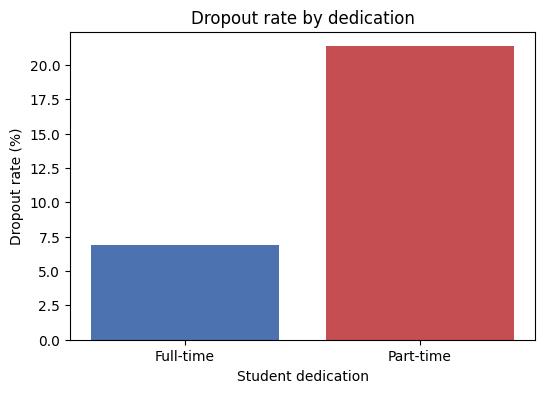

In [7]:
#grouping by dedication and calculating the average dropout rate
dedication_analysis = df.groupby('dedication')['dropout'].mean() * 100

print(dedication_analysis)

#creating a bar plot to compare dropout rates by dedication
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(dedication_analysis.index, dedication_analysis.values, color=["#4C72B0", "#C44E52"])
ax.set_title("Dropout rate by dedication")
ax.set_ylabel("Dropout rate (%)")
ax.set_xlabel("Student dedication")
plt.show()

The percentage of Part-time students who dropped out (~21%) is almost 3 times bigger than the percentage of Full-time student dropouts (~7%), so the university may want to pay special attention to Part-time enrolled students.

Let's look closley at Part-time enrolled students

In [8]:
#analyzing correlations for part-time students
df_part_time = df_encoded[df_encoded['dedication_Part-time'] == 1]
df_part_time_corr = df_part_time.corr()["dropout"].sort_values(ascending=False).drop("dropout")
print(df_part_time_corr)

credits_remaining            0.198017
admission_pathway_NCA        0.122654
admission_pathway_NLE        0.092024
admission_pathway_NAI        0.054462
admission_pathway_NAP        0.048691
degree_preference            0.045619
admission_pathway_NRO        0.027619
n_courses                    0.004951
admission_pathway_NTE       -0.007561
credits_enrolled            -0.019481
admission_pathway_NCF       -0.021374
admission_pathway_NSC       -0.021374
entry_grade                 -0.025487
admission_pathway_BMA       -0.030253
highest_year                -0.063074
lms_events                  -0.090969
wifi_days                   -0.095766
lms_minutes                 -0.102084
admission_pathway_Unknown   -0.144683
credits_passed              -0.274137
avg_course_grade            -0.344606
performance                 -0.345891
admission_pathway_ANT             NaN
admission_pathway_NIE             NaN
admission_pathway_NSA             NaN
dedication_Full-time              NaN
dedication_P

Apart from performance, average course grade and credits passed (which were also strongly correlated with dropouts for **all students**, so it makes sense they are also strongly correlated with the Part-time ones), the **credits remaining** feature is highly correlated with Part-time students (~0.2) in opposition to our previous correlation scores (~0.05).

We may conclude from this that Part-time students may be dropping out due to the amount of remaining credits they have to the end of their degree.

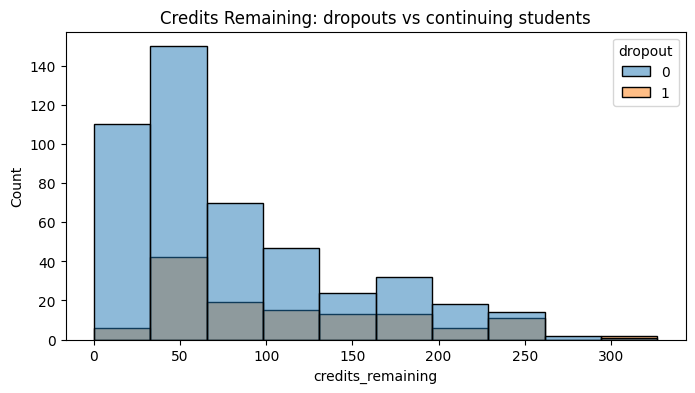

In [9]:
#histogram of credits remaining for dropouts vs continuing students
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_part_time, x="credits_remaining", hue="dropout", bins=10, ax=ax)
ax.set_title("Credits Remaining: dropouts vs continuing students")
plt.show()

We can see that as the **amount of credits remaining goes up, the ratio od dropout to continuing students keeps getting worse**. (At the **300** credits remaining threshold the number of dropout students is larger than the number of the continuing ones).

This could be caused by the fact that since Part-time enrolled students have less working hours than the Full-time enrolled ones, it takes them longer to earn all of their credits. The vision of more far more years of study ahead of them (in comparision to Full-time students, who will obtain their degree faster) may be demotivating for them, causing the students to drop out.

Lets also analyze the **admission pathways**, since their correlation scores range from ~-0.06 to ~0.07.

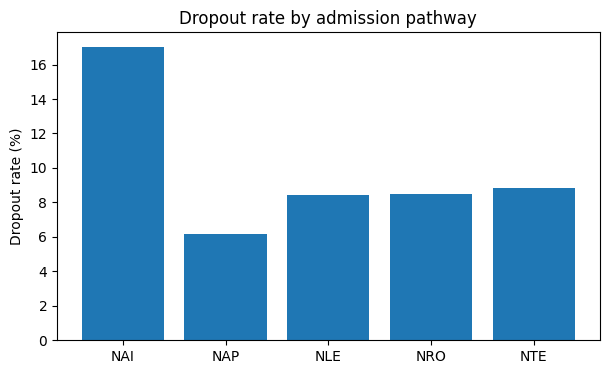

In [25]:
#bar chart: dropout rate by admission_pathway (top 5 pathways only)
top5 = df["admission_pathway"].value_counts().drop("Unknown").head(5).index
subset = df[df["admission_pathway"].isin(top5)]
rate = subset.groupby("admission_pathway")["dropout"].mean() * 100

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(rate.index, rate.values)          # which attribute holds the numbers?
ax.set_title("Dropout rate by admission pathway")
ax.set_ylabel("Dropout rate (%)")
plt.show()

We can clearly see that students enrolled through the **NAI** admission pathway are most likely to dropout

**2) Engagment**

All engagment features seem to be negatively correlated with student dropouts, which means **the less students engage with the university, the more likely they are to dropout**.

Lets analyze the most impactful engagement feature: **lms minutes** (~0.1)

dropout
0    14594.368616
1     8114.239625
Name: lms_minutes, dtype: float64


C:\Users\Maja Kropielnicka\AppData\Local\Temp\ipykernel_20736\2576935261.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot=sns.barplot(x=lms_dropout_rate.index, y=lms_dropout_rate.values, palette=["#4C72B0", "#C44E52"])


Text(0.5, 1.0, 'Average LMS minutes by dropout status')

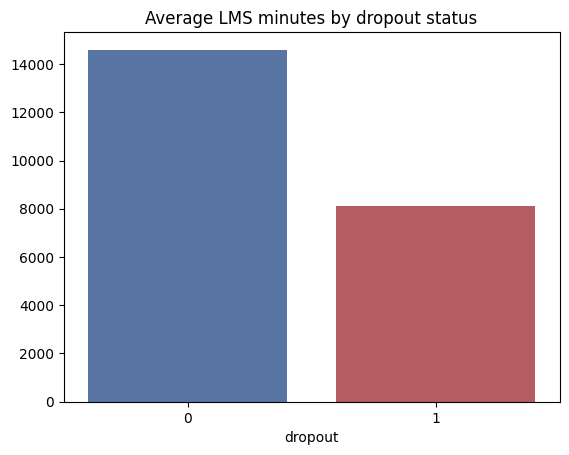

In [10]:
#bar plot of average LMS minutes by dropout status
lms_dropout_rate = df_encoded.groupby('dropout')['lms_minutes'].mean()
print(lms_dropout_rate)
plot=sns.barplot(x=lms_dropout_rate.index, y=lms_dropout_rate.values, palette=["#4C72B0", "#C44E52"])
plot.set_title("Average LMS minutes by dropout status")

We can see that non-dropout students averaged around **6000 more lms minutes** than dropouts.

Lets additionally also check how these engagement factors play off on **performance**, since that was the most impactful feature.

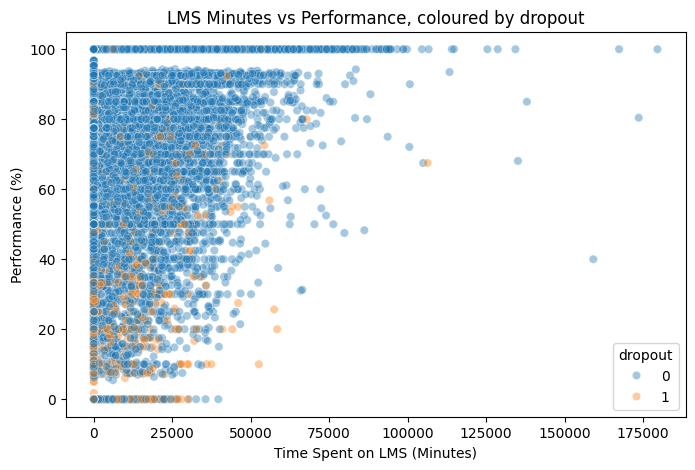

In [11]:
#scatter plot of lms_minutes vs performance, colored by dropout status
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="lms_minutes", y="performance",
                hue="dropout", alpha=0.4, ax=ax)
ax.set_title("LMS Minutes vs Performance, coloured by dropout")
ax.set_xlabel("Time Spent on LMS (Minutes)")
ax.set_ylabel("Performance (%)")
plt.show()

We can see an interesting pattern among the **non-dropouts**: The higher the performance, the more likely is the student to be spending more time on LMS.

On the other hand, when looking at the **dropouts**, it is very unlikely for a student to have high performance and no time spent on LMS.

From this we can conclude, that the **more time spent on LMS**, the **better the performance**, the **lesser chances for dropout**.

Lets also check the LMS stats for Part- vs Full-time enrolled students

dedication
Full-time    14403.199728
Part-time     4695.122689
Name: lms_minutes, dtype: float64


C:\Users\Maja Kropielnicka\AppData\Local\Temp\ipykernel_20736\3541542857.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot=sns.barplot(x=lms_summary.index, y=lms_summary.values, palette=["#4C72B0", "#C44E52"])


Text(0.5, 1.0, 'Average LMS minutes by dedication')

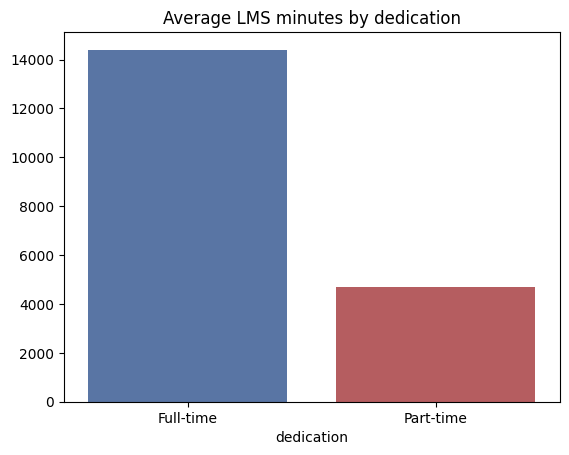

In [12]:
#bar plot of average lms_minutes by dedication
lms_summary = df.groupby('dedication')['lms_minutes'].mean()
print(lms_summary)
plot=sns.barplot(x=lms_summary.index, y=lms_summary.values, palette=["#4C72B0", "#C44E52"])
plot.set_title("Average LMS minutes by dedication")

We can see that on average, Full-time students spend ~8000 more minutes on LMS than Part-time ones, which proves that a student who is enrolled **Part-time** or has **lower LMS stats** is **more likely to dropout**.

**3) Academic performance**

Out of academic performance features, **credits enrolled** seem to be the most strongly correlated with dropouts (~-0.12)

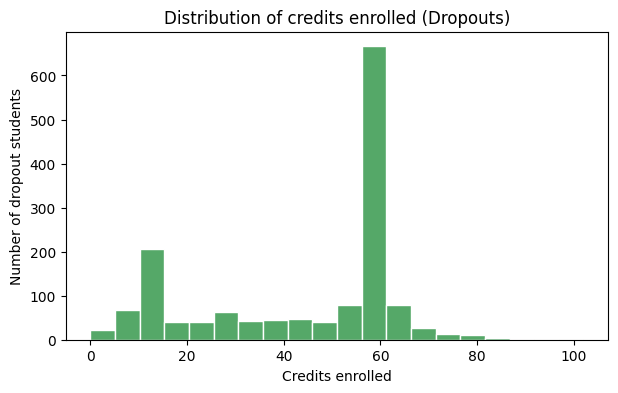

In [26]:
#histogram of credits enrolled for dropout students
dropout_students = df[df["dropout"] == 1]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dropout_students["credits_enrolled"].dropna(), bins=20, color="#55A868", edgecolor="white")
ax.set_title("Distribution of credits enrolled (Dropouts)")
ax.set_xlabel("Credits enrolled")
ax.set_ylabel("Number of dropout students")
plt.show()

We can see that the biggest spike in student dropouts is at the 60 credits mark - which makes sense, since 60 credits is the standard credits enrollment amount for the full academic year.

But lets look closely at the beginning of the histogram - there seems to be another spike in number of dropouts around the **15 credits mark**. The university may want to pay attention to students who have only around 15 credits enrolled.

We already analyzed the **credits remaining** feature and we made the observation, that it is a key feature in Part-time enrolled students dropouts. Lets run the same histogram on credits remaining as we did with credits enrolled.

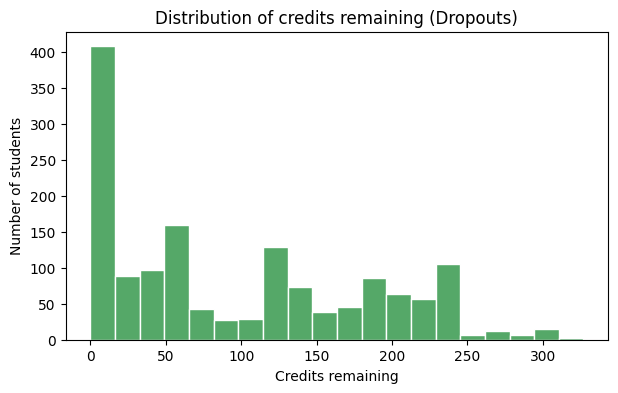

In [14]:
#histogram of credits remaining for dropout students
dropout_students = df[df["dropout"] == 1]
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(dropout_students["credits_remaining"].dropna(), bins=20, color="#55A868", edgecolor="white")
ax.set_title("Distribution of credits remaining (Dropouts)")
ax.set_xlabel("Credits remaining")
ax.set_ylabel("Number of students")
plt.show()

We can see that the most student dropouts happen when a student has 0 credits remaining - this observation doesnt give us too much, since it could be a technical glitch: a student completed all their courses -> the credits remaining score comes down to 0 -> the system still didn't update their status of "graduated", labeling them as a **dropout with 0 credits**.

But as with the credits enrolled histogram, there seem to be certain spikes for certain credits remaining amounts, like **50**, **125** and just before **250**.

Lets also look at the highest year factor, since it was correlated with dropouts at ~-0.1.

C:\Users\Maja Kropielnicka\AppData\Local\Temp\ipykernel_20736\2430962142.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  plot=sns.barplot(x=year_dropout_rate.index, y=year_dropout_rate.values, palette=["#4C72B0", "#C44E52"])
C:\Users\Maja Kropielnicka\AppData\Local\Temp\ipykernel_20736\2430962142.py:3: UserWarning: 
The palette list has fewer values (2) than needed (5) and will cycle, which may produce an uninterpretable plot.
  plot=sns.barplot(x=year_dropout_rate.index, y=year_dropout_rate.values, palette=["#4C72B0", "#C44E52"])


Text(0.5, 1.0, 'Average Dropout Rate by Year')

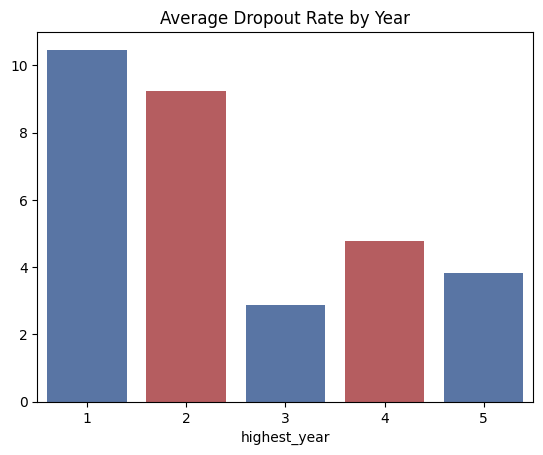

In [15]:
#barplot of average dropout rate by highest year
year_dropout_rate = df_encoded.groupby('highest_year')['dropout'].mean() * 100
plot=sns.barplot(x=year_dropout_rate.index, y=year_dropout_rate.values, palette=["#4C72B0", "#C44E52"])
plot.set_title("Average Dropout Rate by Year")

We can see that the most dropouts occur in the **first** year by studies, closely followed by the **second** and **fourth**.

**4) Outcome**

Now for our outcome category: the features of this category were the most strongly correlated with dropouts.

First, lets look at **performance**:

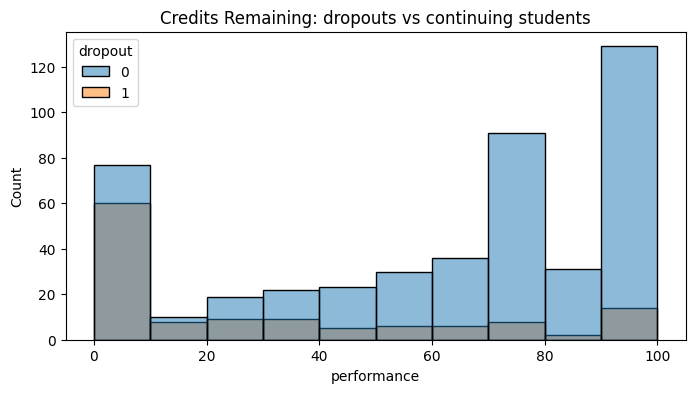

In [ ]:
#histogram of credits remaining for dropouts vs continuing students
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_part_time, x="performance", hue="dropout", bins=10, ax=ax)
ax.set_title("Performance: dropouts vs continuing students")
plt.show()

We can see that at **very low performance stats**, there are almost as many **dropouts** as there are **continuing students**.

Now for **average course grade**:

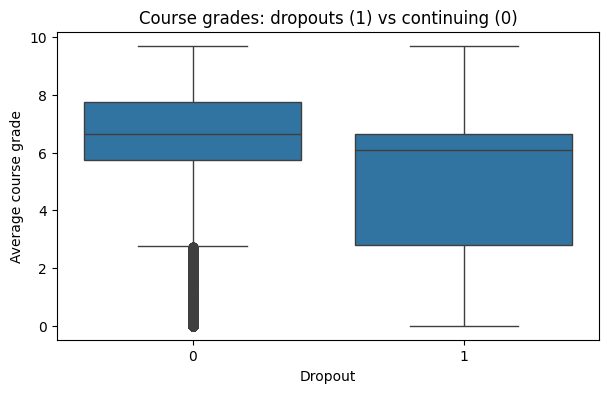

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x="dropout", y="avg_course_grade", ax=ax)
ax.set_title("Course grades: dropouts (1) vs continuing (0)")
ax.set_xlabel("Dropout")
ax.set_ylabel("Average course grade")
plt.show()

We can conclude that overall, the average course grades for dropout students are similar to the average grades of continuing students, but there are generally **a lot more** dropout students who achieve very low course grades.

Lets analyze grades with performance as well:

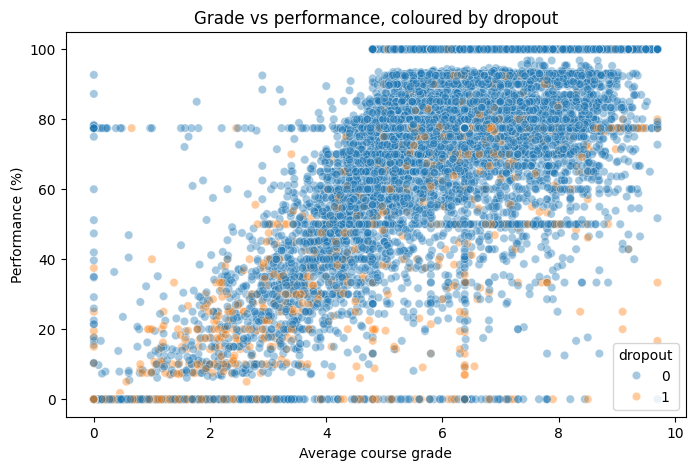

In [17]:
#scatter plot of average course grade vs performance, colored by dropout status
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df, x="avg_course_grade", y="performance",
                hue="dropout", alpha=0.4, ax=ax)
ax.set_title("Grade vs performance, coloured by dropout")
ax.set_xlabel("Average course grade")
ax.set_ylabel("Performance (%)")
plt.show()

We see that the points generally line up in a **f(x)=x** function, meaning they are very closely correlated. As **average course grade** goes up, **performance** goes up appropriately.

Whats more, we see a lot of **extreme cases** aswell: when looking at the top and bottom of the graph, we see many students who:

1) have 0% performance but the avg course grade spans from 0-8
2) have 100% performance but the avg course grade spans from 4-10.

Nevertheless, even from these extreme cases, we can generally conclude that **the better average course grade**, the **better the performance**, the **lesser chances of dropout**.

We have one last feature to analyze: **credits passed**.

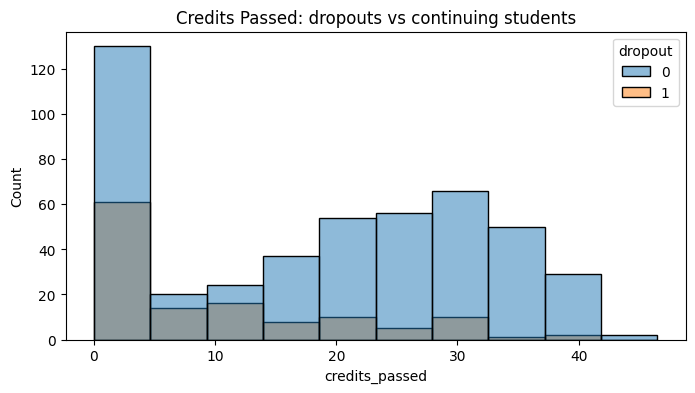

In [18]:
#histogram of credits passed for dropouts vs continuing students
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df_part_time, x="credits_passed", hue="dropout", bins=10, ax=ax)
ax.set_title("Credits Passed: dropouts vs continuing students")
plt.show()

We can see from the plot that overall, the **less credits** have been passed the **more likely** the student is to dropout.

# **Summary**

The most important early-warning signals for student dropouts are:

**1) Low performance** 
> Performance was the number one most correlated feature with student dropouts: the worse the performance, the more likely a student is to drop out.

**2) Low amount of credits passed**
> From our analysis, we comcluded, that the less credits have been passed the more likely the student is to dropout.

**3) Average course grade**
> Higher average course grade contributes to better performance, which of course correlates greatly with a lesser chance for student dropout.

Other influencial features include:

**Low amount of credits enrolled** - Students with about 15 credits in their study programme are at greater risk for dropout.

**Dedication** - Part-time enrolled students are at much greater risk of dropout than the Full-time enrolled ones. We concluded that the main reason for this is the amount of credits remaining: Since Part-time students have less working days in their schedule, it takes much longer for them to finish their degree - the vision of more years of study ahead od them may be de-motivating for them.

**Engagement** - Our study showed that high interaction with the University is closely correlated with high performance, meaning that the more students engage with LMS, the less likely they are to dropout.

**Admission pathway** - Students enrolled throygh the NAI admission pathway are more likely to dropout.

**Year of study** - Students are at greatest risk of dropout in their first year of study.


    